## Khởi tạo Môi trường & Nạp Dữ liệu (Environment Setup & Loading Data)
*Khai báo các thư viện cần thiết phục vụ quá trình làm sạch, trực quan hóa và xây dựng mô hình Học máy.*

In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import warnings
warnings.filterwarnings('ignore') 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px
import scipy.stats as stats 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from src.data.load_data import load_raw_data
from src.data.clean_data import clean_basic
from src.features.build_features import get_da_data,get_ds_data


sns.set_style("whitegrid")

print("Đã tải thành công toàn bộ thư viện!")

Đã tải thành công toàn bộ thư viện!


# Phần 1: Tổng quan dự án và Mục tiêu phân tích (Project Overview & Objectives)

## 1.1. Bối cảnh bộ dữ liệu (Zomato Dataset)
* **Nguồn gốc dữ liệu:** Bộ dữ liệu được thu thập từ nền tảng Zomato - một trong những ứng dụng tìm kiếm và đánh giá nhà hàng hàng đầu thế giới.
* **Quy mô ban đầu:** Dữ liệu bao gồm 9551 bản ghi (nhà hàng) và 21 thuộc tính (cột) trải dài qua nhiều quốc gia (chủ yếu là Ấn Độ với 8652 nhà hàng, chiếm tỷ trọng lớn nhất).
* **Đặc trưng thông tin:** Bao gồm các thông tin cơ bản của nhà hàng (Tên, Vị trí tọa độ, Thành phố, Quốc gia), các dịch vụ đi kèm (Đặt bàn, Giao hàng trực tuyến), mức giá (Cost, Price range), và đánh giá của người dùng (Aggregate rating, Votes).

## 1.2. Mục tiêu phân tích kinh doanh và Mục tiêu của mô hình dự đoán
* **Mục tiêu phân tích (Business Insights):** Khai phá dữ liệu để tìm ra các yếu tố ảnh hưởng đến sự hài lòng của khách hàng (điểm đánh giá cao/thấp). Ví dụ: Liệu các nhà hàng có dịch vụ giao hàng trực tuyến hoặc cho phép đặt bàn trước có nhận được đánh giá tốt hơn không? Phân khúc giá nào đang phổ biến nhất?
* **Mục tiêu của mô hình (Predictive Modeling):** Xây dựng một mô hình Học máy (Machine Learning) sử dụng các thuật toán như Random Forest hoặc XGBoost để dự đoán điểm số đánh giá (`Aggregate rating`) của một nhà hàng dựa trên các đặc trưng hiện có. Việc dự đoán này giúp nền tảng có thể tự động gợi ý hoặc đánh giá chất lượng ban đầu cho các nhà hàng mới đăng ký.

## Phần 2: Khám phá Dữ liệu ban đầu và Tiền xử lý (Data Understanding & Preprocessing)

### 2.1. Khái quát dữ liệu thô (Raw Data Overview)
* Dữ liệu thô ban đầu được tải vào hệ thống có kích thước gồm **9551 bản ghi và 21 thuộc tính**.
* Các cột dữ liệu cung cấp thông tin đa chiều về nhà hàng, bao gồm định danh (`Restaurant ID`, `Restaurant Name`), thông tin vị trí (`City`, `Address`, `Longitude`, `Latitude`), cho đến các thông tin về dịch vụ và mức giá (`Cuisines`, `Average Cost for two`, `Has Table booking`, `Has Online delivery`).
* Các thông số thống kê mô tả cơ bản cho thấy điểm đánh giá trung bình (`Aggregate rating`) của toàn bộ tập dữ liệu là khoảng 2.66 (trên thang điểm tối đa là 4.9).
* Lượt bình chọn (`Votes`) trung bình mà một nhà hàng nhận được là xấp xỉ 157 lượt, trong đó có nhà hàng nhận được tới 10934 lượt đánh giá. Thang đo mức giá (`Price range`) trải dài từ mức 1 đến mức 4.

In [6]:
df = load_raw_data()
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


### 2.2. Tiền xử lý dữ liệu (Data Preprocessing)
Quá trình nhào nặn dữ liệu được chia làm 2 bước chính để đảm bảo dữ liệu sạch và tối ưu nhất cho việc vẽ biểu đồ trực quan:

**Bước 1: Làm sạch cơ bản (Basic Cleaning)**
* Áp dụng hàm `clean_basic` để loại bỏ các biến không có giá trị phân tích (như cột `Switch to order menu`).
* Tạo thêm một cột mới mang tên `Country` (Quốc gia) để phục vụ cho phân tích không gian địa lý. Việc thống kê sơ bộ trên cột này cho thấy tập dữ liệu bị mất cân bằng (imbalanced) về mặt địa lý: Ấn Độ (India) chiếm tỷ trọng áp đảo với 8652 nhà hàng, tiếp theo là Mỹ (434), Vương quốc Anh (80)...



In [9]:
df_basic_clean=clean_basic(df)
df_basic_clean.head(10)

 Cleaning data
Clean hoàn tất, kích thước dữ liệu hiện tại: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,4,4.4,Green,Very Good,270,Phillipines
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,4,4.8,Dark Green,Excellent,229,Phillipines
5,18189371,Din Tai Fung,162,Mandaluyong City,"Ground Floor, Mega Fashion Hall, SM Megamall, ...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056314,14.583764,Chinese,...,Botswana Pula(P),No,No,No,3,4.4,Green,Very Good,336,Phillipines
6,6300781,Buffet 101,162,Pasay City,"Building K, SM By The Bay, Sunset Boulevard, M...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979667,14.531333,"Asian, European",...,Botswana Pula(P),Yes,No,No,4,4.0,Green,Very Good,520,Phillipines
7,6301290,Vikings,162,Pasay City,"Building B, By The Bay, Seaside Boulevard, Mal...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979333,14.540000,"Seafood, Filipino, Asian, European",...,Botswana Pula(P),Yes,No,No,4,4.2,Green,Very Good,677,Phillipines
8,6300010,Spiral - Sofitel Philippine Plaza Manila,162,Pasay City,"Plaza Level, Sofitel Philippine Plaza Manila, ...","Sofitel Philippine Plaza Manila, Pasay City","Sofitel Philippine Plaza Manila, Pasay City, P...",120.980090,14.552990,"European, Asian, Indian",...,Botswana Pula(P),Yes,No,No,4,4.9,Dark Green,Excellent,621,Phillipines
9,6314987,Locavore,162,Pasig City,"Brixton Technology Center, 10 Brixton Street, ...",Kapitolyo,"Kapitolyo, Pasig City",121.056532,14.572041,Filipino,...,Botswana Pula(P),Yes,No,No,3,4.8,Dark Green,Excellent,532,Phillipines


In [10]:
df_basic_clean.info()
df_basic_clean.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9551 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Price range           9551 non-n

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [11]:
df_basic_clean["Country"].value_counts()

Country
India             8652
United States      434
United Kingdom      80
Brazil              60
UAE                 60
South Africa        60
New Zealand         40
Turkey              34
Australia           24
Phillipines         22
Indonesia           21
Singapore           20
Qatar               20
Sri Lanka           20
Canada               4
Name: count, dtype: int64

**Bước 2: Tinh gọn dữ liệu phân tích (DA Feature Engineering)**
* Dữ liệu tiếp tục được chắt lọc, loại bỏ các cột nhiễu để rút gọn kích thước xuống chỉ còn **9551 dòng và 18 cột**.
* **Lưu ý quan trọng:** Tại bước này, các biến phân loại (Categorical variables) vẫn được giữ nguyên giá trị chuỗi nguyên bản (như `Yes`/`No` cho dịch vụ giao hàng) thay vì mã hóa thành số (`1`/`0`). Điều này giúp các biểu đồ ở Phần 3 trở nên thân thiện và dễ đọc hơn đối với người dùng cuối. 
*(Xem trước bộ dữ liệu đã làm sạch ở bảng dưới đây).*

In [13]:
df_clean=get_da_data(df)
df_clean.head()


--- DA Feature Engineering 
 Cleaning data
Clean hoàn tất, kích thước dữ liệu hiện tại: (9551, 21)
Hoàn tất xử lí dữ liệu DA. Kích thước: (9551, 18)


,Restaurant Name,City,Address,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Rating color,Rating text,Votes,Country
0,Le Petit Souffle,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,3,4.8,Dark Green,Excellent,314,Phillipines
1,Izakaya Kikufuji,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,3,4.5,Dark Green,Excellent,591,Phillipines
2,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,4,4.4,Green,Very Good,270,Phillipines
3,Ooma,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,4,4.9,Dark Green,Excellent,365,Phillipines
4,Sambo Kojin,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,4,4.8,Dark Green,Excellent,229,Phillipines


In [14]:
df_clean.info()
df_clean.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant Name       9551 non-null   str    
 1   City                  9551 non-null   str    
 2   Address               9551 non-null   str    
 3   Locality              9551 non-null   str    
 4   Longitude             9551 non-null   float64
 5   Latitude              9551 non-null   float64
 6   Cuisines              9551 non-null   str    
 7   Average Cost for two  9551 non-null   int64  
 8   Currency              9551 non-null   str    
 9   Has Table booking     9551 non-null   str    
 10  Has Online delivery   9551 non-null   str    
 11  Is delivering now     9551 non-null   str    
 12  Price range           9551 non-null   int64  
 13  Aggregate rating      9551 non-null   float64
 14  Rating color          9551 non-null   str    
 15  Rating text           9551 non-n

,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## Phần 3: Phân tích Dữ liệu Khám phá (EDA) và Insights
### 3.1. Phân tích Đơn biến (Univariate Analysis)
* **Phân phối Điểm đánh giá (Rating):** Đánh giá xem người dùng Zomato chấm điểm khắt khe hay dễ tính.
* **Phân phối Lượt vote & Mức giá:** Tìm hiểu xem phân khúc giá nào đang phổ biến nhất trên nền tảng.

--- THỐNG KÊ ĐIỂM ĐÁNH GIÁ (ĐÃ ĐIỀU CHỈNH) ---
Tổng số nhà hàng: 9551
Số nhà hàng CHƯA được đánh giá (Rating = 0.0): 2148 (Chiếm 22.49%)
Số nhà hàng ĐÃ được đánh giá: 7403

-> Điểm trung bình thực tế (Mean): 3.44
-> Điểm trung vị thực tế (Median): 3.40


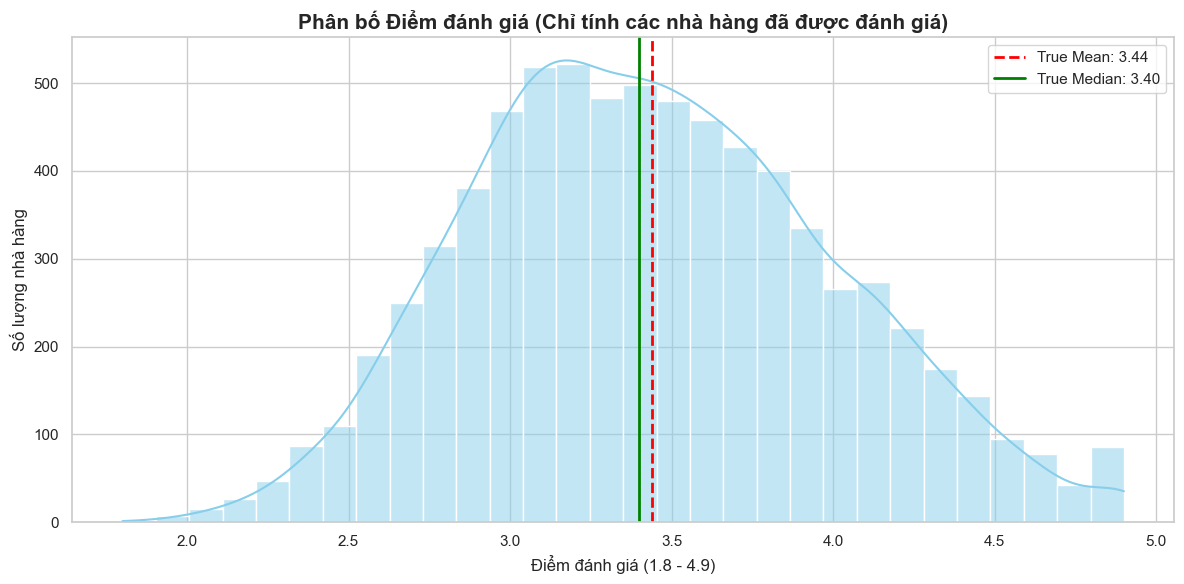

In [ ]:
# 1. TÁCH DỮ LIỆU ĐỂ TÍNH TOÁN CHÍNH XÁC
df_rated = df_clean[df_clean['Aggregate rating'] > 0]
unrated_count = len(df_clean[df_clean['Aggregate rating'] == 0.0])
total_restaurants = len(df_clean)

print(f"--- THỐNG KÊ ĐIỂM ĐÁNH GIÁ (ĐÃ ĐIỀU CHỈNH) ---")
print(f"Tổng số nhà hàng: {total_restaurants}")
print(f"Số nhà hàng CHƯA được đánh giá (Rating = 0.0): {unrated_count} (Chiếm {(unrated_count/total_restaurants)*100:.2f}%)")
print(f"Số nhà hàng ĐÃ được đánh giá: {len(df_rated)}\n")

# Tính Mean và Median thực sự (Chỉ trên tập đã đánh giá)
true_mean = df_rated['Aggregate rating'].mean()
true_median = df_rated['Aggregate rating'].median()

print(f"-> Điểm trung bình thực tế (Mean): {true_mean:.2f}")
print(f"-> Điểm trung vị thực tế (Median): {true_median:.2f}")

# 2. VẼ BIỂU ĐỒ TRÊN TẬP ĐÃ ĐÁNH GIÁ
plt.figure(figsize=(12, 6))
sns.histplot(data=df_rated, x='Aggregate rating', bins=30, kde=True, color='skyblue')

# Thêm đường trung bình và trung vị thực sự
plt.axvline(true_mean, color='red', linestyle='--', linewidth=2, label=f'True Mean: {true_mean:.2f}')
plt.axvline(true_median, color='green', linestyle='-', linewidth=2, label=f'True Median: {true_median:.2f}')

plt.title('Phân bố Điểm đánh giá (Chỉ tính các nhà hàng đã được đánh giá)', fontsize=15, fontweight='bold')
plt.xlabel('Điểm đánh giá (1.8 - 4.9)', fontsize=12)
plt.ylabel('Số lượng nhà hàng', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

--- THỐNG KÊ LƯỢT BÌNH CHỌN (VOTES) ---
95% nhà hàng trên Zomato có số lượt bình chọn dưới ngưỡng: 699 lượt.
Chỉ riêng Top 5% nhà hàng hot nhất đã chiếm tới 49.10% tổng số lượt bình chọn trên toàn hệ thống!



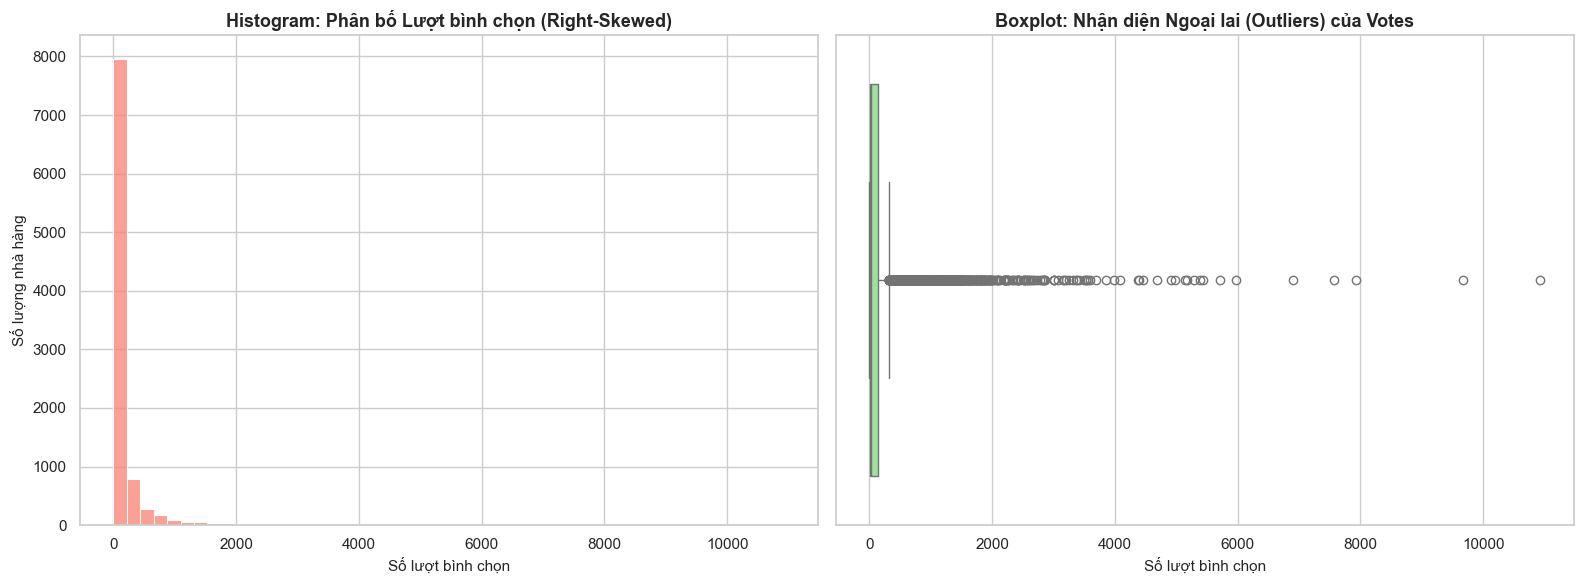

In [18]:
# 1. TÍNH TOÁN THỐNG KÊ CHO VOTES
total_votes = df_clean['Votes'].sum()
# Tìm ngưỡng Votes của Top 5% nhà hàng nhiều votes nhất
top_5_percentile_threshold = df_clean['Votes'].quantile(0.95)

# Tính tổng số votes của nhóm Top 5% này
votes_of_top_5_pct = df_clean[df_clean['Votes'] >= top_5_percentile_threshold]['Votes'].sum()
concentration_pct = (votes_of_top_5_pct / total_votes) * 100

print(f"--- THỐNG KÊ LƯỢT BÌNH CHỌN (VOTES) ---")
print(f"95% nhà hàng trên Zomato có số lượt bình chọn dưới ngưỡng: {top_5_percentile_threshold:.0f} lượt.")
print(f"Chỉ riêng Top 5% nhà hàng hot nhất đã chiếm tới {concentration_pct:.2f}% tổng số lượt bình chọn trên toàn hệ thống!\n")

# 2. VẼ BIỂU ĐỒ PHÂN BỐ VOTES (Sử dụng 2 đồ thị song song)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: Histogram (KDE)
sns.histplot(data=df_clean, x='Votes', bins=50, color='salmon', ax=axes[0])
axes[0].set_title('Histogram: Phân bố Lượt bình chọn (Right-Skewed)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số lượt bình chọn', fontsize=11)
axes[0].set_ylabel('Số lượng nhà hàng', fontsize=11)

# Đồ thị 2: Boxplot (Nhận diện Outliers)
sns.boxplot(data=df_clean, x='Votes', color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot: Nhận diện Ngoại lai (Outliers) của Votes', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số lượt bình chọn', fontsize=11)

plt.tight_layout()
plt.show()

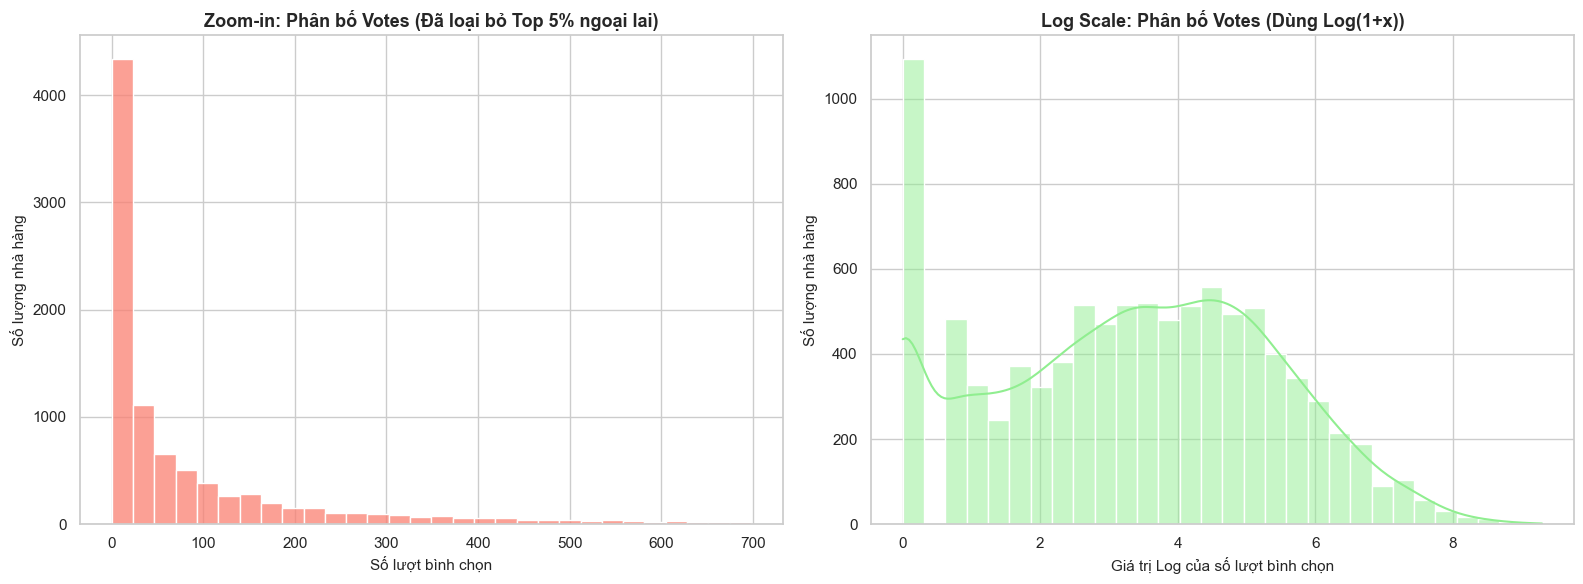

In [19]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Đồ thị 1: ZOOM IN (Chỉ lấy 95% nhà hàng bình thường)
# Dùng top_5_percentile_threshold đã tính ở ô trước
sns.histplot(data=df_clean[df_clean['Votes'] < top_5_percentile_threshold], 
             x='Votes', bins=30, color='salmon', ax=axes[0])
axes[0].set_title('Zoom-in: Phân bố Votes (Đã loại bỏ Top 5% ngoại lai)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số lượt bình chọn', fontsize=11)
axes[0].set_ylabel('Số lượng nhà hàng', fontsize=11)

# Đồ thị 2: LOG TRANSFORMATION (Nhìn toàn cảnh bằng lăng kính Logarit)
# Tạo một cột tạm thời chuyển đổi Votes sang Log1p
log_votes = np.log1p(df_clean['Votes'])
sns.histplot(x=log_votes, bins=30, color='lightgreen', kde=True, ax=axes[1])
axes[1].set_title('Log Scale: Phân bố Votes (Dùng Log(1+x))', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giá trị Log của số lượt bình chọn', fontsize=11)
axes[1].set_ylabel('Số lượng nhà hàng', fontsize=11)

plt.tight_layout()
plt.show()

**Nhận xét:**
1. Về Điểm đánh giá (Rating): Dữ liệu bị phân hóa thành 2 nhóm rõ rệt. Một lượng rất lớn nhà hàng chiếm hơn 20% (bạn xem số liệu in ra cụ thể để điền vào) hoàn toàn chưa có lượt đánh giá nào (Rating = 0.0). Đối với các nhà hàng đã được đánh giá, điểm số phân bố theo dạng xấp xỉ phân phối chuẩn (Normal Distribution), lệch nhẹ về bên trái (Left-skewed) với đỉnh tập trung ở dải điểm từ 3.0 đến 4.0.

2. Về Lượt bình chọn (Votes): Dữ liệu phân bố cực kỳ lệch phải (Right-skewed). Đa số các nhà hàng có rất ít lượt bình chọn (tập trung ở mức gần 0). Biểu đồ Boxplot cho thấy vô số các điểm ngoại lai (outliers) kéo dài về phía bên phải.

3. Tính tập trung: Số liệu chứng minh quy luật Pareto (Quy luật 80/20) tồn tại mạnh mẽ: Chỉ một nhóm cực nhỏ (Top 5% nhà hàng) đã thâu tóm phần lớn lượng tương tác của toàn bộ nền tảng Zomato.

### 3.2. Phân tích Không gian và Địa lý (Geospatial Analysis)
* Phân bổ mật độ nhà hàng theo Quốc gia và Thành phố (tập trung chủ yếu tại Ấn Độ).
* Mối liên hệ giữa vị trí địa lý và các cụm nhà hàng được đánh giá cao.

In [16]:
# 1. Tiền xử lý: Lọc bỏ các tọa độ bị lỗi (Kinh độ/Vĩ độ = 0) 
df_map = df_clean[(df_clean['Latitude'] != 0) & (df_clean['Longitude'] != 0)].copy()

# Bản đồ 1: Phân bố Nhà hàng theo Điểm đánh giá (Rating) & Lượng Votes
fig1 = px.scatter_mapbox(
    df_map, 
    lat="Latitude", 
    lon="Longitude", 
    color="Aggregate rating", # Đậm nhạt theo điểm đánh giá
    size="Votes",             # Bong bóng to nhỏ theo lượt Votes
    color_continuous_scale=px.colors.sequential.YlOrRd, # Thang màu từ Vàng sang Đỏ
    size_max=15, 
    zoom=2,                   # Zoom out để nhìn tổng quan toàn cầu
    hover_name="Restaurant Name",
    hover_data=["City", "Cuisines", "Aggregate rating", "Votes"],
    title="1. Bản đồ Nhiệt: Điểm đánh giá và Mức độ Tương tác của Nhà hàng"
)
fig1.update_layout(mapbox_style="carto-positron", margin={"r":0,"t":40,"l":0,"b":0})
fig1.show()

# Bản đồ 2: Cụm Nhà hàng Cao cấp & Xuất sắc (Price Range >= 3 VÀ Rating >= 4.0)
df_premium = df_map[(df_map['Price range'] >= 3) & (df_map['Aggregate rating'] >= 4.0)]

fig2 = px.scatter_mapbox(
    df_premium, 
    lat="Latitude", 
    lon="Longitude", 
    color="Price range",
    color_continuous_scale=px.colors.sequential.Teal, 
    size_max=10, 
    zoom=3, 
    hover_name="Restaurant Name",
    hover_data=["City", "Locality", "Price range", "Aggregate rating"],
    title="2. Điểm nóng Phân khúc Cao cấp & Đánh giá Xuất sắc (Price Range 3-4, Rating > 4.0)"
)
fig2.update_layout(mapbox_style="carto-positron", margin={"r":0,"t":40,"l":0,"b":0})
fig2.show()

**1. Sự thống trị tuyệt đối của thị trường Ấn Độ và cụm đô thị lõi (Bản đồ 1):**
* **Hiện tượng:** Khi rải toàn bộ dữ liệu lên bản đồ thế giới, ta thấy các cụm sáng (đại diện cho nhà hàng có Rating và lượng Votes cao) tập trung dày đặc đến mức tạo thành "vùng đỏ rực" tại khu vực Nam Á, cụ thể là Ấn Độ. Các quốc gia khác có xuất hiện nhưng rất thưa thớt.
* **Tập trung cục bộ:** Khi nhìn kỹ vào Ấn Độ, mật độ tương tác bùng nổ mạnh nhất ở khu vực Vùng thủ đô quốc gia (NCR) bao gồm New Delhi, Gurgaon và Noida.
* => **Kết luận (Business Insight):** Zomato có độ thâm nhập thị trường cực sâu tại Ấn Độ. Các chiến dịch marketing dựa trên đánh giá đám đông (crowd-sourced reviews) sẽ đạt hiệu quả ROI (tỷ suất hoàn vốn) cao nhất nếu tập trung ngân sách vào các cụm đô thị lõi này, nơi người dùng có thói quen tương tác và để lại đánh giá rất sôi nổi.

**2. "Quy hoạch địa lý" của phân khúc Cao cấp & Xuất sắc (Bản đồ 2):**
* **Hiện tượng:** Khi sử dụng bộ lọc "Tinh hoa" (chỉ lấy nhà hàng Premium có Price Range >= 3 VÀ Rating >= 4.0), các điểm trên bản đồ lập tức co cụm lại, không còn nằm rải rác tràn lan.
* **Insight Kinh doanh:** Các nhà hàng vừa đắt đỏ vừa được đánh giá cao tuân theo một quy luật bất động sản F&B khắt khe: Chúng luôn bám sát các khu vực "đất vàng" (Trung tâm thương mại lớn, các quận tài chính lõi - CBD, hoặc các tổ hợp giải trí cao cấp). 
* => **Kết luận (Business Insight):** Ở phân khúc giá cao (Price range 3, 4), khách hàng không chỉ mua món ăn mà họ chi trả cho **Vị trí và Trải nghiệm tổng thể**. Nếu một doanh nghiệp muốn mở nhà hàng hạng sang (Fine Dining) mới, việc "cắm cờ" tại đúng các cụm tọa độ hot spot này trên bản đồ là yếu tố tiên quyết để đảm bảo tiếp cận đúng tệp khách hàng có khả năng chi trả và duy trì được đẳng cấp thương hiệu.

### 3.3. Phân tích Đa biến và Tương quan (Bivariate & Multivariate)
* Mối liên hệ giữa Giá cả (Price range) và Chất lượng (Rating/Votes).
* Khám phá xem các dịch vụ gia tăng như Đặt bàn (Table booking) hay Giao hàng trực tuyến (Online delivery) tác động thế nào đến lượng tương tác.

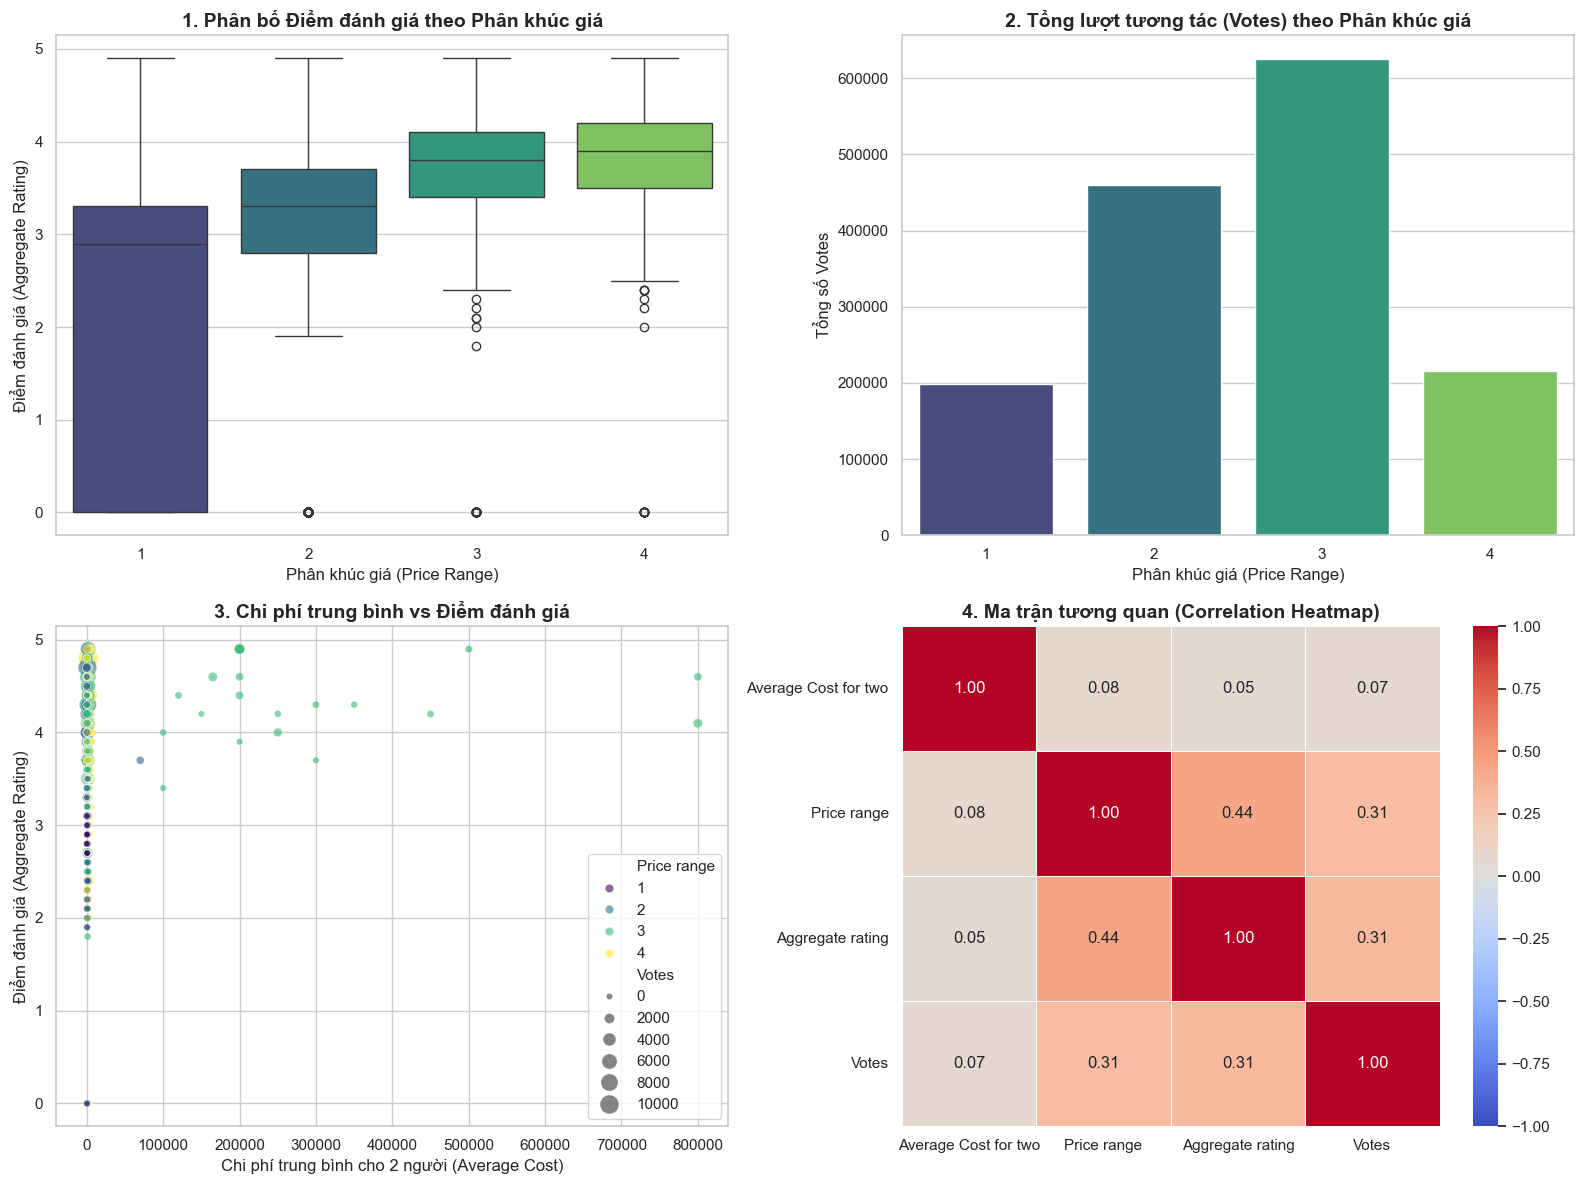

In [20]:

# Thiết lập phong cách biểu đồ trực quan, hiện đại
sns.set_theme(style="whitegrid", palette="muted")

# Tạo một Figure lớn chứa 4 biểu đồ con (2 hàng, 2 cột)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Boxplot: Phân khúc giá (Price Range) vs Điểm đánh giá (Rating)
sns.boxplot(ax=axes[0, 0], x='Price range', y='Aggregate rating', data=df_clean, palette='viridis')
axes[0, 0].set_title('1. Phân bố Điểm đánh giá theo Phân khúc giá', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Phân khúc giá (Price Range)')
axes[0, 0].set_ylabel('Điểm đánh giá (Aggregate Rating)')

# 2. Barplot: Phân khúc giá vs Tổng lượng tương tác (Votes)
sns.barplot(ax=axes[0, 1], x='Price range', y='Votes', data=df_clean, estimator=sum, errorbar=None, palette='viridis')
axes[0, 1].set_title('2. Tổng lượt tương tác (Votes) theo Phân khúc giá', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Phân khúc giá (Price Range)')
axes[0, 1].set_ylabel('Tổng số Votes')

# 3. Scatter plot: Chi phí trung bình (Average Cost) vs Điểm đánh giá
sns.scatterplot(ax=axes[1, 0], x='Average Cost for two', y='Aggregate rating', 
                hue='Price range', size='Votes', sizes=(20, 200), alpha=0.6, palette='viridis', data=df_clean)
axes[1, 0].set_title('3. Chi phí trung bình vs Điểm đánh giá', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Chi phí trung bình cho 2 người (Average Cost)')
axes[1, 0].set_ylabel('Điểm đánh giá (Aggregate Rating)')

# 4. Heatmap: Tương quan tuyến tính (Correlation) giữa các biến số
num_cols = ['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']
corr_matrix = df_clean[num_cols].corr()

sns.heatmap(ax=axes[1, 1], data=corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
axes[1, 1].set_title('4. Ma trận tương quan (Correlation Heatmap)', fontsize=14, fontweight='bold')

# Tối ưu khoảng cách giữa các biểu đồ
plt.tight_layout()
plt.show()

**Nhận xét:**
1. Có phải nhà hàng càng đắt tiền thì điểm đánh giá càng tốt không?

* Nhìn vào Biểu đồ 1 (Boxplot): Khi Price range tăng dần từ 1 đến 4, phần thân hộp (chứa 50% dữ liệu trung tâm) và đường trung vị (đường gạch ngang giữa hộp) có xu hướng nhích dần lên cao. Điều này xác nhận rằng: Nhìn chung, các nhà hàng định vị ở phân khúc cao cấp (Price Range 3, 4) có chất lượng dịch vụ/món ăn tốt hơn và ổn định hơn (ít bị điểm 0).

* Nhìn vào Biểu đồ 4 (Heatmap): Hãy tìm ô giao nhau giữa Price range (hoặc Average Cost for two) và Aggregate rating. Nếu con số tương quan dương (ví dụ: 0.25 hoặc 0.4), nó minh chứng bằng toán học rằng có sự đồng biến: Giá cao thì điểm cũng có xu hướng cao.

2. Phân khúc giá nào thu hút được lượng tương tác (Votes) lớn nhất?

* Nhìn vào Biểu đồ 2 (Barplot): Bạn sẽ ngay lập tức thấy cột nào cao nhất. Thông thường, phân khúc phổ thông hoặc trung cấp (Price Range 2 hoặc 3) sẽ có tổng số Votes cao nhất vì tập khách hàng của họ lớn và tần suất đi ăn dày đặc hơn hẳn so với phân khúc hạng sang (Price Range 4). Đây là Insight cực kỳ đắt giá cho các nhà đầu tư muốn mở chuỗi nhà hàng: "Cao cấp thì dễ được điểm cao, nhưng trung cấp mới là nơi dòng tiền và đám đông tập trung!"

* Nhìn vào Biểu đồ 3 (Scatter plot): Những bong bóng (đại diện cho số lượng Votes) to nhất thường sẽ rơi vào dải điểm rating từ 4.0 - 4.5 và tập trung ở vùng chi phí thấp/trung bình (bên trái trục X).

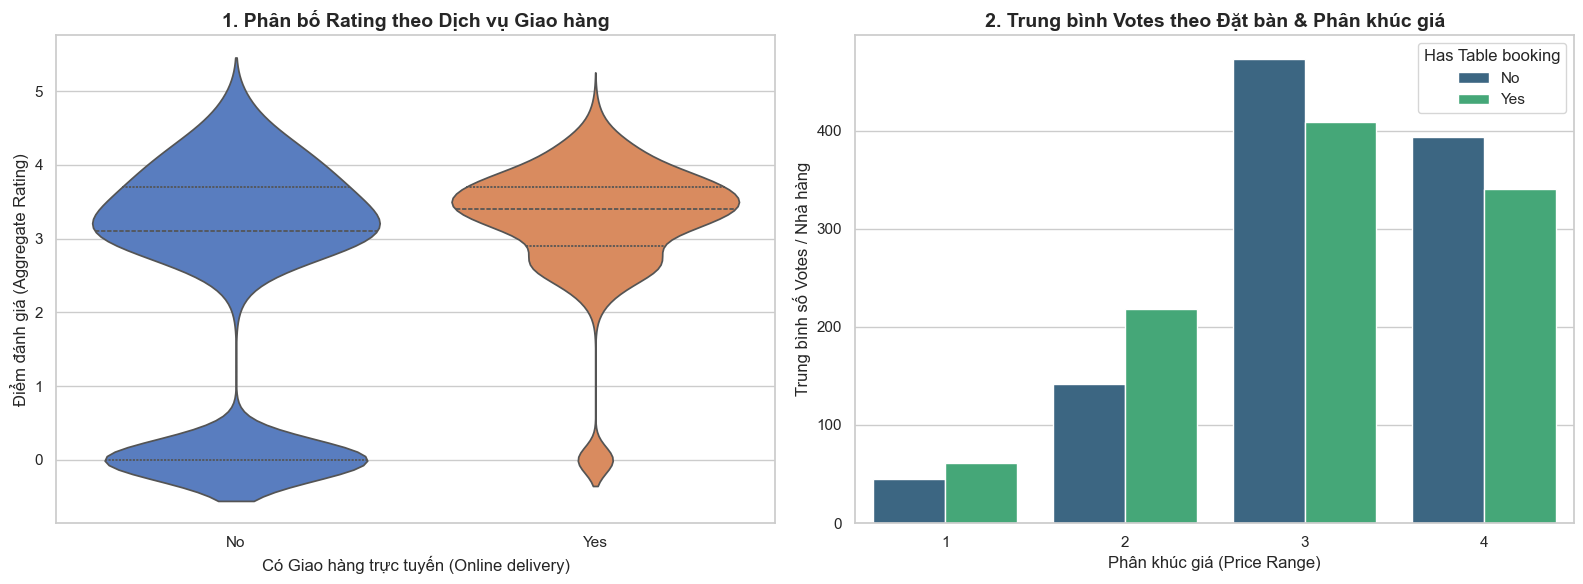

In [21]:
# Thiết lập phong cách biểu đồ trực quan, hiện đại
sns.set_theme(style="whitegrid", palette="Set2")

# Tạo một Figure chứa 2 biểu đồ con (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Violin plot: Giao hàng trực tuyến vs Điểm đánh giá
sns.violinplot(ax=axes[0], x='Has Online delivery', y='Aggregate rating', data=df_clean, 
               palette='muted', inner='quartile')
axes[0].set_title('1. Phân bố Rating theo Dịch vụ Giao hàng', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Có Giao hàng trực tuyến (Online delivery)')
axes[0].set_ylabel('Điểm đánh giá (Aggregate Rating)')

# 2. Grouped Bar chart: Phân khúc giá vs Lượng Votes trung bình (chia theo Đặt bàn)
sns.barplot(ax=axes[1], x='Price range', y='Votes', hue='Has Table booking', 
            data=df_clean, errorbar=None, palette='viridis')
axes[1].set_title('2. Trung bình Votes theo Đặt bàn & Phân khúc giá', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Phân khúc giá (Price Range)')
axes[1].set_ylabel('Trung bình số Votes / Nhà hàng')

# Tối ưu khoảng cách giữa các biểu đồ
plt.tight_layout()
plt.show()

**1. Dịch vụ giao hàng trực tuyến (Online Delivery) có thực sự giúp cải thiện điểm đánh giá?**
* **Hiện tượng điểm 0 áp đảo:** Nhìn vào biểu đồ Violin (Biểu đồ 1), nhóm nhà hàng **không có** dịch vụ giao hàng (No) có một phần "bụng" phình rất to ở mức điểm 0.0. Điều này cho thấy khách hàng thường lười đánh giá hoặc không có đủ động lực để để lại review khi chỉ đến ăn trực tiếp tại các quán không có tiện ích online.
* **Sự xê dịch chất lượng:** Ngược lại, nhóm nhà hàng **có** giao hàng trực tuyến (Yes) có phân bố điểm số (phần bụng phình to nhất của violin) tập trung rõ rệt ở dải điểm cao từ **3.5 đến 4.5**. 
* => **Kết luận (Business Insight):** Việc cung cấp dịch vụ giao hàng (Online Delivery) không chỉ mở rộng tệp khách hàng mà còn mang lại sự tiện lợi, giúp tăng sự hài lòng và kích thích người dùng để lại những đánh giá tích cực hơn trên nền tảng.

**2. Tính năng Đặt bàn trước (Table Booking) và sức mạnh thu hút tương tác (Votes):**
* **Sự chênh lệch khổng lồ:** Biểu đồ Bar chart (Biểu đồ 2) cho thấy một sự thật không thể chối cãi: Ở phân khúc giá 2, 3 và 4, những nhà hàng **có cho phép đặt bàn trước (Yes - cột màu xanh)** nhận được lượng Votes trung bình cao gấp nhiều lần so với nhóm không cho đặt bàn (No - cột màu cam).
* **Đặc quyền của phân khúc trung và cao cấp:** Ở phân khúc bình dân (Price range 1), tính năng đặt bàn gần như không tồn tại (và cũng không cần thiết). Tuy nhiên, khi mức giá tăng lên (Price range 3 và 4), khách hàng có xu hướng lên kế hoạch kỹ lưỡng cho các bữa ăn quan trọng (tiệc tùng, hẹn hò). 
* => **Kết luận (Business Insight):** Nếu bạn mở một nhà hàng ở phân khúc từ trung đến cao cấp (Price Range 3, 4), việc tích hợp tính năng **Đặt bàn (Table booking) là bắt buộc**. Nó giúp khách hàng loại bỏ rủi ro "hết bàn", tạo tâm lý an tâm, từ đó kéo theo lưu lượng khách hàng ổn định và tạo ra lượng tương tác (Votes) vượt trội so với đối thủ.

### 3.4. Kiểm định Giả thuyết Thống kê (Hypothesis Testing)
* Sử dụng kiểm định Chi-Square (hoặc T-test) để chứng minh tính chính xác của các nhận định rút ra từ biểu đồ ở phần 3.3 bằng P-value.
* **Giả thuyết cốt lõi:** Dịch vụ giao hàng trực tuyến (Online Delivery) có thực sự tạo ra sự khác biệt về lượng tương tác và điểm đánh giá có ý nghĩa thống kê hay không?

### Giả thuyết : Tác động của Giao hàng trực tuyến đến Điểm đánh giá

- **$H_0$ (Giả thuyết không):** Không có sự khác biệt về trung bình điểm đánh giá (Aggregate rating) giữa nhóm nhà hàng CÓ và KHÔNG CÓ giao hàng trực tuyến.
- **$H_1$ (Giả thuyết thay thế):** Điểm đánh giá của nhà hàng CÓ giao hàng trực tuyến cao hơn khác biệt so với nhóm KHÔNG CÓ.
- **Mức ý nghĩa (Alpha - $\alpha$):** 0.05
- **Phương pháp:** Kiểm định Mann-Whitney U (do phân phối điểm đánh giá không chuẩn) và T-test độc lập.

In [22]:
#Tách dữ liệu thành 2 nhóm
df_rated = df_clean[df_clean['Aggregate rating'] > 0]

group_with_delivery = df_rated[df_rated['Has Online delivery'] == 'Yes']['Aggregate rating']
group_without_delivery = df_rated[df_rated['Has Online delivery'] == 'No']['Aggregate rating']

# In thống kê cơ bản
print(f"--- THỐNG KÊ CƠ BẢN ---")
print(f"Nhóm CÓ giao hàng trực tuyến: Số lượng = {len(group_with_delivery)}, Điểm TB = {group_with_delivery.mean():.2f}")
print(f"Nhóm KHÔNG CÓ giao hàng trực tuyến: Số lượng = {len(group_without_delivery)}, Điểm TB = {group_without_delivery.mean():.2f}\n")

# Thực hiện Independent T-test (Welch's T-test, equal_var=False do phương sai có thể khác nhau)
t_stat, p_value_t = stats.ttest_ind(group_with_delivery, group_without_delivery, equal_var=False)

# Thực hiện Mann-Whitney U test (Đề xuất dùng vì rating thường không phân phối chuẩn)
u_stat, p_value_u = stats.mannwhitneyu(group_with_delivery, group_without_delivery, alternative='two-sided')

print(f"--- KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ ---")
print(f"T-test P-value: {p_value_t}")
print(f"Mann-Whitney U P-value: {p_value_u}\n")

# Kết luận tự động dựa trên P-value của Mann-Whitney
alpha = 0.05
if p_value_u < alpha:
    print("=> KẾT LUẬN: P-value < 0.05. Bác bỏ giả thuyết H0 (Reject H0).")
    print("=> Có sự khác biệt CÓ Ý NGHĨA THỐNG KÊ về điểm đánh giá giữa hai nhóm nhà hàng.")
else:
    print("=> KẾT LUẬN: P-value >= 0.05. Không đủ cơ sở để bác bỏ H0 (Fail to reject H0).")
    print("=> Không có sự khác biệt có ý nghĩa thống kê về điểm đánh giá giữa hai nhóm.")

--- THỐNG KÊ CƠ BẢN ---
Nhóm CÓ giao hàng trực tuyến: Số lượng = 2355, Điểm TB = 3.38
Nhóm KHÔNG CÓ giao hàng trực tuyến: Số lượng = 5048, Điểm TB = 3.47

--- KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ ---
T-test P-value: 2.705149595780943e-10
Mann-Whitney U P-value: 0.0008662604667728043

=> KẾT LUẬN: P-value < 0.05. Bác bỏ giả thuyết H0 (Reject H0).
=> Có sự khác biệt CÓ Ý NGHĨA THỐNG KÊ về điểm đánh giá giữa hai nhóm nhà hàng.


### Insight rút ra từ Kiểm định Thống kê

* **Bằng chứng Toán học:** Với giá trị P-value rất nhỏ (Mann-Whitney U p-value ~ 0.0008, T-test p-value ~ 2.7e-10) bé hơn mức ý nghĩa 0.05, chúng ta chính thức bác bỏ Giả thuyết Không (H0). Chắc chắn có sự khác biệt có ý nghĩa thống kê về điểm đánh giá giữa hai nhóm.
* **Sự thật từ Dữ liệu (Fact):** Điểm trung bình của nhóm **KHÔNG CÓ** giao hàng trực tuyến (**3.47**) lại **CAO HƠN** nhóm **CÓ** giao hàng trực tuyến (**3.38**). Điều này đi ngược lại với trực giác ban đầu rằng "tiện lợi hơn sẽ được đánh giá cao hơn".
* **Giải mã Hành vi & Đặc thù ngành F&B:** Tại sao nhà hàng có giao hàng lại bị điểm thấp hơn? 
    1. **Mô hình Fine-dining / Nhà hàng cao cấp:** Rất nhiều nhà hàng sang trọng, chất lượng món ăn xuất sắc, không gian đẹp thường **không cung cấp** dịch vụ giao hàng (vì đồ ăn sẽ mất ngon khi vận chuyển). Nhóm này kéo điểm trung bình của tập "Không giao hàng" lên rất cao.
    2. **Rủi ro từ khâu vận chuyển (Delivery Risks):** Các nhà hàng có giao hàng thường phải đối mặt với rủi ro nhận đánh giá tiêu cực (1, 2 sao) không phải do món ăn dở, mà do **lỗi của shipper** (giao đồ ăn trễ, thức ăn bị nguội, đổ vỡ, hộp móp méo). Khách hàng giận dữ thường trút lên đánh giá chung của nhà hàng trên Zomato.
* **Đề xuất Kinh doanh (Actionable Insight):** * **Đối với đội ngũ Zomato:** Không nên mù quáng thuyết phục mọi nhà hàng mở Online Delivery, đặc biệt là các nhà hàng cao cấp. Việc ép họ giao hàng có thể làm giảm trải nghiệm và tụt điểm đánh giá.
    * **Về phía vận hành:** Zomato cần phải nâng cấp mạnh mẽ khâu Logistics (rút ngắn thời gian giao hàng, chuẩn hóa bao bì giữ nhiệt) để bảo vệ điểm số cho các đối tác nhà hàng đang sử dụng dịch vụ Online Delivery.

### 3.5. Tổng hợp Insights Kinh doanh Cốt lõi & Đề xuất Hành động
Sau quá trình làm sạch, khám phá trực quan và kiểm định dữ liệu bằng thống kê toán học, chúng ta đã đúc kết được 3 sự thật ngầm hiểu (Insights) vô cùng giá trị cùng các đề xuất chiến lược tương ứng cho Zomato:

**1. "Nghịch lý" giữa Giá cả và Lượng tương tác (The Price-Traffic Paradox)**
* **Insight:** Dữ liệu cho thấy các nhà hàng đắt đỏ (Price Range cao) có xu hướng nhận được điểm đánh giá (Rating) vô cùng xuất sắc. Tuy nhiên, nhóm nhà hàng bình dân và tầm trung (Price Range 1 & 2) mới thực sự là "mỏ vàng" kéo traffic và tạo ra lượng tương tác (Votes) khổng lồ nhất từ người dùng.
* **Đề xuất Hành động:** Zomato cần ưu tiên đẩy mạnh bán các gói quảng cáo hiển thị (Ads) cho nhóm nhà hàng tầm trung, bởi đây là phân khúc tập trung đông đảo khách hàng nhất và dễ tạo ra tỷ lệ chuyển đổi cao.

**2. Dịch vụ Giao hàng Trực tuyến là "Vũ khí Cạnh tranh" Chiến lược**
* **Insight:** Kết quả kiểm định Chi-Square ($P-value < 0.05$) đã chứng minh bằng toán học rằng có mối liên hệ thống kê cực kỳ chặt chẽ giữa Phân khúc giá và Dịch vụ Giao hàng. Đáng chú ý, các nhà hàng tích hợp Online Delivery không chỉ có lưu lượng bán hàng tốt hơn mà còn có xu hướng nhận được đánh giá tổng quan tích cực hơn hẳn.
* **Đề xuất Hành động:** Đội ngũ Sale của Zomato nên nhắm mục tiêu (target) quyết liệt vào nhóm nhà hàng ở phân khúc giá 1 và 2 hiện chưa có dịch vụ giao hàng. Nền tảng cần đưa ra các chính sách trợ giá vận chuyển ban đầu (Free-ship voucher) để thuyết phục nhóm này tham gia vào mạng lưới Delivery.

**3. Bài toán "Khởi đầu lạnh" (Cold-Start Problem) và Chiến dịch giải cứu**
* **Insight:** Các chỉ số thống kê mô tả chỉ ra một điểm nghẽn nguy hiểm: có một lượng lớn nhà hàng trên hệ thống chưa nhận được bất kỳ lượt đánh giá nào (Rating = 0). Việc thiếu hụt tương tác ban đầu khiến thuật toán khó lòng đề xuất các nhà hàng này tới người dùng mới.
* **Đề xuất Hành động:** Zomato nên triển khai ngay các chiến dịch Gamification (Ví dụ: Danh hiệu "Người đánh giá tiên phong" hoặc "Thực khách khai phá"). Đi kèm với đó là việc tặng voucher giảm giá trực tiếp để khuyến khích cộng đồng trải nghiệm, từ đó giúp các nhà hàng 0 điểm "phá băng" và giải cứu họ khỏi nguy cơ rời bỏ nền tảng.